# 03 — Aprendizaje Semisupervisado
### Freesound Audio Tagging 2019

Seguimos la misma estrategia del cuadernillo base con MNIST:
1. Usamos K-Means para identificar representantes por cluster
2. Asignamos a cada cluster la etiqueta de su representante más cercano en `train_curated`
3. Propagamos esas etiquetas a todo `train_noisy`
4. Comparamos el rendimiento contra un clasificador supervisado puro

**Hipótesis**: con solo las ~4.970 etiquetas limpias de curated podemos etiquetar
los ~19.815 audios de noisy y mejorar el clasificador final.

## 1. Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import LabelSpreading, LabelPropagation
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

FEATURES_DIR = Path("features")

# Cargar todo
X_curated_scaled = np.load(FEATURES_DIR / "X_curated_scaled.npy")
y_curated        = np.load(FEATURES_DIR / "y_curated.npy")
X_noisy_scaled   = np.load(FEATURES_DIR / "X_noisy_scaled.npy")
y_noisy_raw      = np.load(FEATURES_DIR / "y_noisy_raw.npy")  # sólo referencia
X_pca_curated    = np.load(FEATURES_DIR / "X_pca_full.npy")
representative_idxs = np.load(FEATURES_DIR / "representative_idxs.npy")

with open(FEATURES_DIR / "kmeans_model.pkl", "rb") as f:
    kmeans = pickle.load(f)
with open(FEATURES_DIR / "pca_model.pkl", "rb") as f:
    pca = pickle.load(f)
with open(FEATURES_DIR / "label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

N_CLASSES = len(le.classes_)
K = kmeans.n_clusters

# PCA también sobre noisy
X_pca_noisy = pca.transform(X_noisy_scaled)

print(f"X_curated_scaled : {X_curated_scaled.shape}")
print(f"X_pca_curated    : {X_pca_curated.shape}")
print(f"X_pca_noisy      : {X_pca_noisy.shape}")
print(f"K (clusters)     : {K}")
print(f"N_CLASSES        : {N_CLASSES}")

X_curated_scaled : (4970, 80)
X_pca_curated    : (4970, 56)
X_pca_noisy      : (19815, 56)
K (clusters)     : 78
N_CLASSES        : 78


## 2. Split de evaluación

Separamos una parte de `curated` como test set (no la usamos para entrenar).
El resto de curated es el conjunto supervisado de referencia.

In [2]:
# Split: 80% train, 20% test (de curated)
X_train_sup, X_test, y_train_sup, y_test = train_test_split(
    X_pca_curated, y_curated, test_size=0.20, random_state=42, stratify=y_curated
)

print(f"Train supervisado : {X_train_sup.shape}")
print(f"Test              : {X_test.shape}")

Train supervisado : (3976, 56)
Test              : (994, 56)


## 3. Baseline — Clasificador supervisado puro

Entrenamos con sólo los datos curated etiquetados.
Este es el techo mínimo que queremos superar con el enfoque semisupervisado.

In [3]:
print("Entrenando clasificador baseline (supervisado puro)...")
log_reg_base = LogisticRegression(max_iter=2000, random_state=42, solver='saga', n_jobs=-1)
log_reg_base.fit(X_train_sup, y_train_sup)

acc_base = log_reg_base.score(X_test, y_test)
print(f"\nAccuracy baseline (supervisado con curated): {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"Datos de entrenamiento usados: {len(X_train_sup)}")

Entrenando clasificador baseline (supervisado puro)...

Accuracy baseline (supervisado con curated): 0.3742 (37.42%)
Datos de entrenamiento usados: 3976


## 4. Propagación de etiquetas con K-Means

- Para cada cluster de K-Means, tomamos todos los puntos de `curated` que caen en ese cluster
- La etiqueta del cluster = clase más frecuente de esos puntos (voting)
- Asignamos esa etiqueta a todos los puntos de `noisy` en el mismo cluster

In [4]:
# Predecir cluster de cada punto de curated y noisy
labels_curated = kmeans.predict(X_pca_curated)
labels_noisy   = kmeans.predict(X_pca_noisy)

# Para cada cluster, encontrar la clase más frecuente en curated (voting)
cluster_to_class = np.zeros(K, dtype=int)
cluster_confidence = np.zeros(K)  # % de acuerdo en ese cluster

for cluster_id in range(K):
    mask = labels_curated == cluster_id
    if mask.sum() == 0:
        # Cluster sin puntos de curated: usar el representante por defecto
        cluster_to_class[cluster_id] = y_curated[representative_idxs[cluster_id]]
        cluster_confidence[cluster_id] = 0.0
    else:
        classes_in_cluster = y_curated[mask]
        unique, counts = np.unique(classes_in_cluster, return_counts=True)
        dominant_class = unique[np.argmax(counts)]
        cluster_to_class[cluster_id] = dominant_class
        cluster_confidence[cluster_id] = counts.max() / len(classes_in_cluster)

print("Mapeo cluster → clase (primeros 10):")
for i in range(min(10, K)):
    clase = le.classes_[cluster_to_class[i]]
    print(f"  Cluster {i:2d} → {clase:<25s} (confianza: {cluster_confidence[i]:.1%})")

print(f"\nConfianza promedio del mapeo: {cluster_confidence.mean():.1%}")

Mapeo cluster → clase (primeros 10):
  Cluster  0 → Accordion                 (confianza: 100.0%)
  Cluster  1 → Chewing_and_mastication   (confianza: 12.1%)
  Cluster  2 → Raindrop                  (confianza: 8.3%)
  Cluster  3 → Female_singing            (confianza: 85.7%)
  Cluster  4 → Accordion                 (confianza: 37.5%)
  Cluster  5 → Child_speech_and_kid_speaking (confianza: 17.5%)
  Cluster  6 → Harmonica                 (confianza: 17.9%)
  Cluster  7 → Electric_guitar           (confianza: 37.5%)
  Cluster  8 → Church_bell               (confianza: 23.1%)
  Cluster  9 → Finger_snapping           (confianza: 17.0%)

Confianza promedio del mapeo: 46.1%


In [5]:
# Propagar etiquetas a noisy
y_noisy_propagated = np.array([cluster_to_class[c] for c in labels_noisy])

print(f"Etiquetas propagadas a noisy: {len(y_noisy_propagated)}")
print(f"Distribución de clases propagadas (top 10):")
unique, counts = np.unique(y_noisy_propagated, return_counts=True)
for cls, cnt in sorted(zip(le.classes_[unique], counts), key=lambda x: -x[1])[:10]:
    print(f"  {cls:<25s}: {cnt}")

Etiquetas propagadas a noisy: 19815
Distribución de clases propagadas (top 10):
  Toilet_flush             : 3434
  Car_passing_by           : 2327
  Applause                 : 1906
  Chirp_and_tweet          : 1754
  Female_singing           : 1204
  Run                      : 1064
  Stream                   : 1030
  Female_speech_and_woman_speaking: 1017
  Mechanical_fan           : 755
  Computer_keyboard        : 627


## 5. Clasificador semisupervisado

Entrenamos con curated + noisy (con etiquetas propagadas).

In [6]:
# Combinar curated (etiquetas limpias) + noisy (etiquetas propagadas)
X_semi = np.vstack([X_pca_curated, X_pca_noisy])
y_semi = np.concatenate([y_curated, y_noisy_propagated])

print(f"Dataset semisupervisado: {X_semi.shape}")
print(f"  Curated (limpias)  : {len(X_pca_curated)}")
print(f"  Noisy (propagadas) : {len(X_pca_noisy)}")

print("\nEntrenando clasificador semisupervisado...")
log_reg_semi = LogisticRegression(max_iter=2000, random_state=42, solver='saga', n_jobs=-1)
log_reg_semi.fit(X_semi, y_semi)

acc_semi = log_reg_semi.score(X_test, y_test)
print(f"\nAccuracy semisupervisado: {acc_semi:.4f} ({acc_semi*100:.2f}%)")
print(f"Mejora sobre baseline  : {(acc_semi - acc_base)*100:+.2f} pp")

Dataset semisupervisado: (24785, 56)
  Curated (limpias)  : 4970
  Noisy (propagadas) : 19815

Entrenando clasificador semisupervisado...

Accuracy semisupervisado: 0.3451 (34.51%)
Mejora sobre baseline  : -2.92 pp


## 6. sklearn LabelSpreading (alternativa)

scikit-learn tiene implementación nativa de propagación de etiquetas.
Usamos una muestra por eficiencia.

In [7]:
# Muestra manejable para LabelSpreading (todo el dataset es demasiado grande)
N_UNLABELED_SAMPLE = 3000  # muestra de noisy
idx_unlabeled = np.random.choice(len(X_pca_noisy), N_UNLABELED_SAMPLE, replace=False)

X_ls = np.vstack([X_pca_curated, X_pca_noisy[idx_unlabeled]])
# -1 indica 'sin etiqueta' para sklearn
y_ls = np.concatenate([y_curated, np.full(N_UNLABELED_SAMPLE, -1)])

print(f"LabelSpreading sobre {len(X_ls)} puntos ({len(X_pca_curated)} etiquetados + {N_UNLABELED_SAMPLE} sin etiquetar)")
print("Entrenando... (puede tardar unos minutos)")

ls = LabelSpreading(kernel='knn', n_neighbors=7, max_iter=30, alpha=0.2)
ls.fit(X_ls, y_ls)

# Evaluar sobre test
acc_ls = ls.score(X_test, y_test)
print(f"\nAccuracy LabelSpreading: {acc_ls:.4f} ({acc_ls*100:.2f}%)")

LabelSpreading sobre 7970 puntos (4970 etiquetados + 3000 sin etiquetar)
Entrenando... (puede tardar unos minutos)

Accuracy LabelSpreading: 0.5131 (51.31%)


## 7. Comparación de resultados

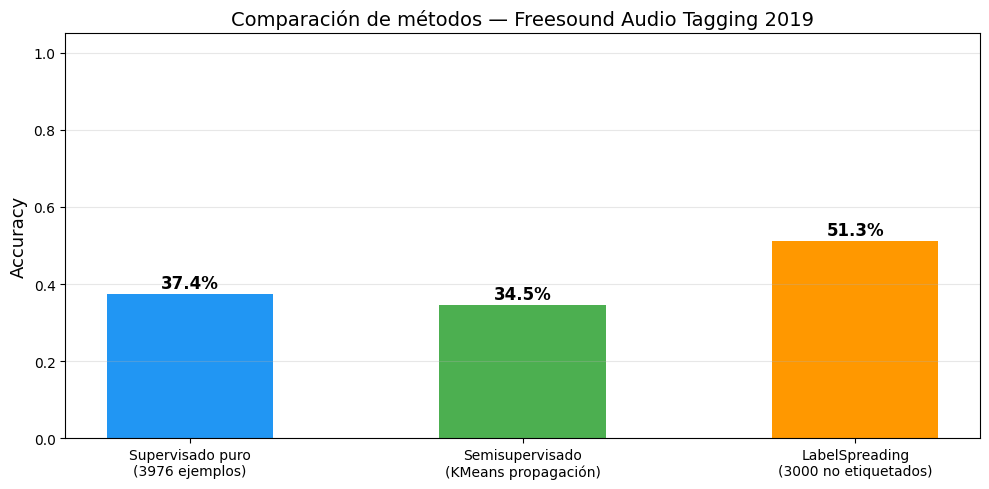


RESUMEN
  Supervisado puro (3976 ejemplos)        : 0.3742
  Semisupervisado (KMeans propagación)    : 0.3451
  LabelSpreading (3000 no etiquetados)    : 0.5131


In [8]:
resultados = {
    f"Supervisado puro\n({len(X_train_sup)} ejemplos)": acc_base,
    f"Semisupervisado\n(KMeans propagación)": acc_semi,
    f"LabelSpreading\n({N_UNLABELED_SAMPLE} no etiquetados)": acc_ls,
}

plt.figure(figsize=(10, 5))
colores = ['#2196F3', '#4CAF50', '#FF9800']
barras = plt.bar(list(resultados.keys()), list(resultados.values()), color=colores, width=0.5)

for bar, val in zip(barras, resultados.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel("Accuracy", fontsize=13)
plt.title("Comparación de métodos — Freesound Audio Tagging 2019", fontsize=14)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("RESUMEN")
print("="*50)
for nombre, acc in resultados.items():
    nombre_limpio = nombre.replace('\n', ' ')
    print(f"  {nombre_limpio:<40s}: {acc:.4f}")

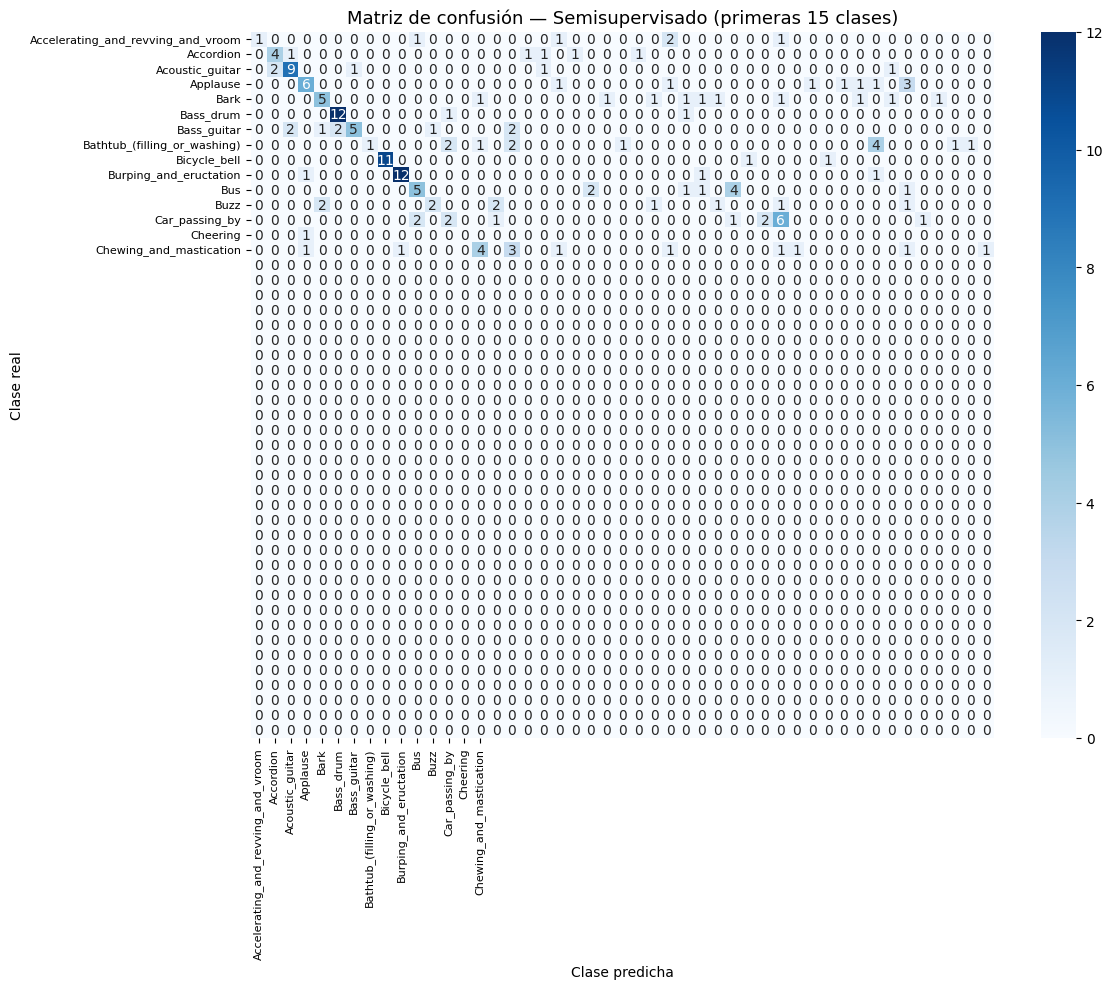

In [9]:
# Matriz de confusión del modelo semisupervisado
y_pred_semi = log_reg_semi.predict(X_test)
cm = confusion_matrix(y_test, y_pred_semi)

# Mostrar sólo las primeras 15 clases para legibilidad
K_SHOW = min(15, N_CLASSES)
mask = y_test < K_SHOW

plt.figure(figsize=(12, 10))
cm_sub = confusion_matrix(y_test[mask], y_pred_semi[mask])
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_[:K_SHOW],
            yticklabels=le.classes_[:K_SHOW])
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(f"Matriz de confusión — Semisupervisado (primeras {K_SHOW} clases)", fontsize=13)
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.tight_layout()
plt.show()

In [10]:
# Guardar modelos para el cuadernillo 04
with open(FEATURES_DIR / "log_reg_base.pkl", "wb") as f:
    pickle.dump(log_reg_base, f)
with open(FEATURES_DIR / "log_reg_semi.pkl", "wb") as f:
    pickle.dump(log_reg_semi, f)

np.save(FEATURES_DIR / "y_noisy_propagated.npy", y_noisy_propagated)
np.save(FEATURES_DIR / "X_pca_noisy.npy", X_pca_noisy)
np.save(FEATURES_DIR / "X_test.npy", X_test)
np.save(FEATURES_DIR / "y_test.npy", y_test)

print("Archivos guardados para el cuadernillo 04.")
print("\n¡Listo para el cuadernillo 04!")

Archivos guardados para el cuadernillo 04.

¡Listo para el cuadernillo 04!
